In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
 
from pathlib import Path
from tqdm import tqdm
from collections import deque
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score
from sklearn.manifold import TSNE
from transformers import BertTokenizerFast
 

In [18]:
CHECKPOINT   = "../../../outputs/checkpoints/amr/unfreeze/node/checkpoint_epoch_0024.pth"
CHECKPOINT_BASE   = "../../../outputs/checkpoints/amr/unfreeze/node/checkpoint_epoch_0004.pth"
JSON_PATH    = "../../../dataset/amrs.json"
BATCH_SIZE   = 32
NEIGHBOR_NUM = 10      # doit correspondre à AMRGraphDatasetGlobal
TOKEN_LENGTH = 10       # idem
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
print(f"Device : {DEVICE}")

Device : cpu


In [19]:
with open(JSON_PATH, "r") as f:
    raw = json.load(f)
 
if isinstance(raw, list):
    penman_strings = raw
elif isinstance(raw, dict):
    key = next(k for k, v in raw.items() if isinstance(v, list))
    penman_strings = raw[key]
else:
    raise ValueError(f"Format JSON inattendu : {type(raw)}")
 
penman_strings = [s for s in penman_strings if isinstance(s, str) and s.strip()]
print(f"AMRs chargés : {len(penman_strings)}")

AMRs chargés : 1295


In [20]:
def load_backbone(checkpoint_path: str) -> nn.Module:
    """Charge le teacher backbone GraphFormers depuis un checkpoint DINO."""
    from dino.models.backbone.graphformers import GraphformersBackbone
 
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    print("Clés checkpoint :", list(ckpt.keys()))
 
    backbone = GraphformersBackbone.from_pretrained()
 
    teacher_sd = ckpt["teacher_state_dict"]
    PREFIX = "backbone."
    stripped = {
        k[len(PREFIX):]: v
        for k, v in teacher_sd.items()
        if k.startswith(PREFIX)
    }
 
    missing, unexpected = backbone.load_state_dict(stripped, strict=False)
    if missing:
        print(f"[WARN] Missing   : {missing[:5]}")
    if unexpected:
        print(f"[WARN] Unexpected: {unexpected[:5]}")
 
    print(f"Backbone chargé depuis {checkpoint_path}")
    return backbone.to(DEVICE).eval()

In [21]:

def _fill_batch(all_texts, neighbor_num, batch_ids, batch_mask, batch_nmask, tokenizer):
    encoded = tokenizer(
        all_texts, max_length=TOKEN_LENGTH, padding="max_length",
        truncation=True, add_special_tokens=True, return_tensors=None,
    )
    real_n  = len(all_texts)
    total_n = neighbor_num + 1
    pad_n   = total_n - real_n
    pad_row = [[0] * TOKEN_LENGTH] * pad_n

    batch_ids.append(torch.tensor(encoded["input_ids"]      + pad_row, dtype=torch.long))
    batch_mask.append(torch.tensor(encoded["attention_mask"] + pad_row, dtype=torch.long))
    batch_nmask.append(torch.tensor([1.0] * real_n + [0.0] * pad_n,    dtype=torch.float))

def _stack(ids, mask, nmask):
    return {
        "input_ids":      torch.stack(ids),
        "attention_mask": torch.stack(mask),
        "neighbor_mask":  torch.stack(nmask),
    }

In [22]:
def penman_to_batch_node(batch_penmans: list, tokenizer, neighbor_num=10, bfs_depth=2) -> dict:
    import penman as penman_lib

    batch_input_ids, batch_attention_mask, batch_neighbor_mask = [], [], []

    for pstr in batch_penmans:
        try:
            graph = penman_lib.decode(pstr)
        except Exception:
            zeros = torch.zeros(neighbor_num + 1, TOKEN_LENGTH, dtype=torch.long)
            mask  = torch.zeros(neighbor_num + 1, dtype=torch.float)
            batch_input_ids.append(zeros)
            batch_attention_mask.append(zeros)
            batch_neighbor_mask.append(mask)
            continue

        node_concept = {inst.source: inst.target for inst in graph.instances()}
        root         = graph.top
        root_concept = node_concept.get(root, root)

        # BFS depth=2, sans shuffle
        visited = {root}
        queue   = [(root, 0)]
        neighbors = []
        while queue:
            current, depth = queue.pop(0)
            if depth >= bfs_depth:
                continue
            for src, role, tgt in graph.triples:
                if role == ":instance" or src != current:
                    continue
                tgt_label = node_concept.get(tgt, str(tgt))
                neighbors.append(f"{role} {tgt_label}")
                if tgt in node_concept and tgt not in visited:
                    visited.add(tgt)
                    queue.append((tgt, depth + 1))

        all_texts = ([root_concept] + neighbors)[: neighbor_num + 1]
        _fill_batch(all_texts, neighbor_num, batch_input_ids, batch_attention_mask, batch_neighbor_mask, tokenizer)

    return _stack(batch_input_ids, batch_attention_mask, batch_neighbor_mask)

In [23]:
def extract_embeddings(backbone: nn.Module, penman_strings: list) -> np.ndarray:
    tokenizer    = BertTokenizerFast.from_pretrained("bert-base-uncased")
    all_embeddings = []
 
    for i in tqdm(range(0, len(penman_strings), BATCH_SIZE), desc="DINO embeddings"):
        batch  = penman_to_batch_node(penman_strings[i:i + BATCH_SIZE], tokenizer)
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        with torch.no_grad():
            emb = backbone(batch)
        all_embeddings.append(emb.cpu().numpy())
 
    return np.vstack(all_embeddings)

In [ ]:
def extract_embeddings_mean_pooling(backbone, penman_strings):
    """
    Pour chaque graphe, encode tous les nœuds comme centre (comme au training)
    et retourne la moyenne des embeddings — représentation graph-level agrégée.
    """
    import penman as penman_lib
    tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    all_embeddings = []

    for pstr in tqdm(penman_strings, desc="Mean-pool embeddings"):
        try:
            graph        = penman_lib.decode(pstr)
            node_concept = {inst.source: inst.target for inst in graph.instances()}
        except Exception:
            all_embeddings.append(np.zeros(768))
            continue

        node_embs = []
        node_ids  = list(node_concept.keys())

        # Encode par batch de BATCH_SIZE nœuds
        for i in range(0, len(node_ids), BATCH_SIZE):
            chunk    = node_ids[i:i + BATCH_SIZE]
            pstr_rep = [pstr] * len(chunk)   # même graphe, centres différents

            batch_ids, batch_mask, batch_nmask = [], [], []
            for node_id in chunk:
                concept   = node_concept[node_id]
                visited   = {node_id}
                queue     = [(node_id, 0)]
                neighbors = []
                while queue:
                    current, depth = queue.pop(0)
                    if depth >= 2:
                        continue
                    for src, role, tgt in graph.triples:
                        if role == ":instance" or src != current:
                            continue
                        tgt_label = node_concept.get(tgt, str(tgt))
                        neighbors.append(f"{role} {tgt_label}")
                        if tgt in node_concept and tgt not in visited:
                            visited.add(tgt)
                            queue.append((tgt, depth + 1))

                all_texts = ([concept] + neighbors)[:NEIGHBOR_NUM + 1]
                _fill_batch(all_texts, NEIGHBOR_NUM, batch_ids, batch_mask, batch_nmask, tokenizer)

            batch = _stack(batch_ids, batch_mask, batch_nmask)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with torch.no_grad():
                emb = backbone(batch).cpu().numpy()
            node_embs.append(emb)

        all_embeddings.append(np.vstack(node_embs).mean(axis=0))

    return np.vstack(all_embeddings)

In [24]:
def build_bert_text(penman_str: str) -> str:
    import penman as penman_lib
    try:
        graph        = penman_lib.decode(penman_str)
        node_concept = {i.source: i.target for i in graph.instances()}
        root         = graph.top
        root_concept = node_concept.get(root, root)

        # BFS depth=2 pour correspondre à penman_to_batch_node
        visited = {root}
        queue   = [(root, 0)]
        neighbors = []
        while queue:
            current, depth = queue.pop(0)
            if depth >= 2:
                continue
            for src, role, tgt in graph.triples:
                if role == ":instance" or src != current:
                    continue
                tgt_label = node_concept.get(tgt, str(tgt))
                neighbors.append(f"{role} {tgt_label}")
                if tgt in node_concept and tgt not in visited:
                    visited.add(tgt)
                    queue.append((tgt, depth + 1))

        return root_concept + " " + " ".join(neighbors)
    except Exception:
        return ""
 
def extract_bert_embeddings(penman_strings: list) -> np.ndarray:
    from transformers import BertModel, BertTokenizerFast
 
    tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    bert      = BertModel.from_pretrained("bert-base-uncased").to(DEVICE).eval()
    texts     = [build_bert_text(p) for p in penman_strings]
    all_embs  = []
 
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="BERT baseline"):
        enc = tokenizer(
            texts[i:i + BATCH_SIZE],
            max_length=TOKEN_LENGTH * (NEIGHBOR_NUM + 1),
            padding=True, truncation=True, return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            out = bert(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
 
    return np.vstack(all_embs)

In [36]:
def extract_node_embeddings(backbone, penman_strings):
    """
    Retourne (embeddings, metadata) où :
    - embeddings : (total_nodes, 768)
    - metadata   : DataFrame avec graph_idx, node_id, concept,
                   depth_from_root, out_degree, in_degree, is_root
    """
    import penman as penman_lib
    tokenizer  = BertTokenizerFast.from_pretrained("bert-base-uncased")
    all_embs   = []
    all_meta   = []

    for graph_idx, pstr in enumerate(tqdm(penman_strings, desc="Node embeddings")):
        try:
            graph        = penman_lib.decode(pstr)
            node_concept = {inst.source: inst.target for inst in graph.instances()}
            root         = graph.top
        except Exception:
            continue

        # Calcul depth_from_root pour chaque nœud (BFS depuis root)
        depth_map = {root: 0}
        queue = [root]
        while queue:
            current = queue.pop(0)
            for src, role, tgt in graph.triples:
                if role == ":instance" or src != current:
                    continue
                if tgt in node_concept and tgt not in depth_map:
                    depth_map[tgt] = depth_map[current] + 1
                    queue.append(tgt)

        # Out/in degree
        out_deg = {n: 0 for n in node_concept}
        in_deg  = {n: 0 for n in node_concept}
        for src, role, tgt in graph.triples:
            if role == ":instance":
                continue
            if src in out_deg:
                out_deg[src] += 1
            if tgt in in_deg:
                in_deg[tgt]  += 1

        node_ids = list(node_concept.keys())

        # Encode par batch
        batch_ids, batch_mask, batch_nmask = [], [], []
        for node_id in node_ids:
            concept   = node_concept[node_id]
            visited   = {node_id}
            queue_bfs = [(node_id, 0)]
            neighbors = []
            while queue_bfs:
                current, depth = queue_bfs.pop(0)
                if depth >= 2:
                    continue
                for src, role, tgt in graph.triples:
                    if role == ":instance" or src != current:
                        continue
                    tgt_label = node_concept.get(tgt, str(tgt))
                    neighbors.append(f"{role} {tgt_label}")
                    if tgt in node_concept and tgt not in visited:
                        visited.add(tgt)
                        queue_bfs.append((tgt, depth + 1))

            all_texts = ([concept] + neighbors)[:NEIGHBOR_NUM + 1]
            _fill_batch(all_texts, NEIGHBOR_NUM,
                        batch_ids, batch_mask, batch_nmask, tokenizer)

            all_meta.append({
                "graph_idx":      graph_idx,
                "node_id":        node_id,
                "concept":        node_concept[node_id],
                "depth_from_root": depth_map.get(node_id, -1),
                "out_degree":     out_deg[node_id],
                "in_degree":      in_deg[node_id],
                "is_root":        int(node_id == root),
            })

        batch = _stack(batch_ids, batch_mask, batch_nmask)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with torch.no_grad():
            emb = backbone(batch).cpu().numpy()
        all_embs.append(emb)

    return np.vstack(all_embs), pd.DataFrame(all_meta)

In [25]:
def graph_depth(graph) -> int:
    root         = graph.top
    node_concept = {i.source: i.target for i in graph.instances()}
    edges        = {}
    for src, role, tgt in graph.triples:
        if role == ":instance" or tgt not in node_concept:
            continue
        edges.setdefault(src, []).append(tgt)
    visited   = {root}
    queue     = deque([(root, 0)])
    max_depth = 0
    while queue:
        node, depth = queue.popleft()
        max_depth = max(max_depth, depth)
        for child in edges.get(node, []):
            if child not in visited:
                visited.add(child)
                queue.append((child, depth + 1))
    return max_depth
 
def node_count(graph)    -> int: return len(list(graph.instances()))
def has_negation(graph)  -> int: return int(any(r == ":polarity" and str(t) == "-"                         for _, r, t in graph.triples))
def has_interrogative(graph) -> int: return int(any(r == ":mode" and str(t) in ("interrogative","imperative") for _, r, t in graph.triples))
def arg_count(graph)     -> int: return sum(1 for _, r, _ in graph.triples if r.startswith(":ARG"))
 
def extract_structural_labels(penman_strings: list) -> pd.DataFrame:
    import penman
    records = []
    for i, pstr in enumerate(penman_strings):
        try:
            g = penman.decode(pstr)
            records.append({
                "idx":               i,
                "depth":             graph_depth(g),
                "node_count":        node_count(g),
                "has_negation":      has_negation(g),
                "has_interrogative": has_interrogative(g),
                "arg_count":         arg_count(g),
            })
        except Exception:
            records.append({
                "idx": i, "depth": None, "node_count": None,
                "has_negation": None, "has_interrogative": None, "arg_count": None,
            })
    return pd.DataFrame(records)

In [26]:
def eval_structural_task(
    embeddings: np.ndarray,
    labels: np.ndarray,
    task_name: str,
    task_type: str = "classification",
    bert_embeddings: np.ndarray = None,
):
    """Compare DINO vs BERT brut sur une tâche structurelle."""
    valid = pd.notna(labels)
    emb   = embeddings[valid]
    lab   = np.array(labels[valid])
 
    print(f"\n{'─'*50}")
    print(f"  Tâche : {task_name}  ({task_type})")
    print(f"  Échantillons valides : {valid.sum()}")
    if task_type == "classification":
        unique, counts = np.unique(lab, return_counts=True)
        for u, c in zip(unique, counts):
            print(f"    classe {u} : {c} ({c/len(lab)*100:.1f}%)")
 
    def run_probe(X, y, name):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=42,
            stratify=y if task_type == "classification" else None,
        )
        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
 
        if task_type == "classification":
            clf  = LogisticRegression(max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr)
            acc  = clf.score(X_te, y_te)
            print(f"\n  [{name}] accuracy = {acc:.4f}")
            print(classification_report(y_te, clf.predict(X_te), zero_division=0))
            return acc
        else:
            reg = Ridge()
            reg.fit(X_tr, y_tr)
            r2  = r2_score(y_te, reg.predict(X_te))
            print(f"\n  [{name}] R² = {r2:.4f}")
            return r2
 
    dino_score = run_probe(emb, lab, "DINO AMR")
 
    if bert_embeddings is not None:
        bert_score = run_probe(bert_embeddings[valid], lab, "BERT brut")
        delta = dino_score - bert_score
        sign  = "✓ DINO > BERT" if delta > 0.02 else ("✗ BERT > DINO" if delta < -0.02 else "≈ équivalent")
        print(f"\n  Delta DINO - BERT : {delta:+.4f}  {sign}")
 
    return dino_score

In [27]:
def tsne_plot(
    embeddings: np.ndarray,
    labels: np.ndarray,
    label_name: str,
    title: str,
    categorical: bool = True,
) -> None:
    print(f"\n── t-SNE → {title} ─────────────────────────────")
    coords = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(embeddings)
 
    valid = pd.notna(labels)
    coords_v = coords[valid]
    labels_v = np.array(labels[valid])
 
    fig, ax = plt.subplots(figsize=(10, 8))
    if categorical:
        for cls in np.unique(labels_v):
            mask = labels_v == cls
            ax.scatter(coords_v[mask, 0], coords_v[mask, 1],
                       label=str(cls), alpha=0.5, s=15, linewidths=0)
        ax.legend(markerscale=2, fontsize=11, title=label_name)
    else:
        sc = ax.scatter(coords_v[:, 0], coords_v[:, 1],
                        c=labels_v.astype(float), cmap="viridis",
                        alpha=0.5, s=15, linewidths=0)
        plt.colorbar(sc, ax=ax, label=label_name)
 
    ax.set_title(f"t-SNE — {title}\ncolorié par {label_name}", fontsize=13)
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
 
    out = f"tsne_{Path(title).stem}_{label_name}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"  Sauvegardé → {out}")

In [28]:
def load_random_backbone() -> nn.Module:
    """GraphFormers avec poids aléatoires (pas de checkpoint DINO, pas de BERT pretraining)."""
    from dino.models.backbone.graphformers import GraphformersBackbone
    
    backbone = GraphformersBackbone.from_pretrained()  # charge BERT pretrained
    
    # Réinitialise uniquement les couches GraphFormers (pas BERT)
    for name, module in backbone.named_modules():
        if "graph_attention" in name or "graph_layer" in name:
            if hasattr(module, "reset_parameters"):
                module.reset_parameters()
            elif hasattr(module, "weight"):
                nn.init.xavier_uniform_(module.weight)
                if hasattr(module, "bias") and module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    print("Backbone GraphFormers random (BERT pretrained, GNN layers réinitialisées)")
    return backbone.to(DEVICE).eval()

In [34]:
backbone        = load_backbone(CHECKPOINT)
backbone_base   = load_backbone(CHECKPOINT_BASE)
backbone_random = load_random_backbone()

Clés checkpoint : ['epoch', 'iteration', 'student_state_dict', 'teacher_state_dict', 'optimizer_state_dict', 'dino_loss_center', 'config', 'metrics', 'timestamp', 'history', 'wandb_run_id', 'scheduler_state_dict']
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone chargé depuis ../../../outputs/checkpoints/amr/unfreeze/node/checkpoint_epoch_0024.pth
Clés checkpoint : ['epoch', 'iteration', 'student_state_dict', 'teacher_state_dict', 'optimizer_state_dict', 'dino_loss_center', 'config', 'metrics', 'timestamp', 'history', 'wandb_run_id', 'scheduler_state_dict']
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone chargé depuis ../../../outputs/checkpoints/amr/unfreeze/node/checkpoint_epoch_0004.pth
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone GraphFormers random (BERT pretrained, GNN layers réinitialisées)


In [ ]:
node_embeddings, node_meta = extract_node_embeddings(backbone, penman_strings)
node_embeddings_base, _ = extract_node_embeddings(backbone_base, penman_strings)
node_embeddings_random, _ = extract_node_embeddings(backbone_random, penman_strings)

nodes_embedding_methods = [
    ("DINO ep24",    node_embeddings),
    ("DINO ep4",     node_embeddings_base),
    ("GFormers rnd", node_embeddings_random),
]

node_tasks = [
    ("depth_from_root", "Profondeur du nœud", "regression"),
    ("out_degree",      "Degré sortant",       "regression"),
    ("in_degree",       "Degré entrant",       "regression"),
    ("is_root",         "Est root ?",          "classification"),
]

node_scores = {name: {} for name, _ in nodes_embedding_methods}

for col, task_name, ttype in node_tasks:
    labels_task = node_meta[col].values
    valid       = pd.notna(labels_task)
    lab         = np.array(labels_task[valid])

    print(f"\n{'═'*60}")
    print(f"  Tâche : {task_name}  ({ttype})")
    print(f"{'═'*60}")

    for method_name, emb in nodes_embedding_methods:
        emb_valid = emb[valid]
        X_tr, X_te, y_tr, y_te = train_test_split(
            emb_valid, lab, test_size=0.2, random_state=42,
            stratify=lab if ttype == "classification" else None,
        )
        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        if ttype == "classification":
            clf   = LogisticRegression(max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr)
            score = clf.score(X_te, y_te)
        else:
            reg   = Ridge()
            reg.fit(X_tr, y_tr)
            score = r2_score(y_te, reg.predict(X_te))

        node_scores[method_name][task_name] = score
        metric_label = "acc" if ttype == "classification" else "R²"
        print(f"  {method_name:<20} {metric_label} = {score:.4f}")

# Tableau récapitulatif
print(f"\n{'═'*60}")
print("  RÉSUMÉ NODE-LEVEL")
print(f"{'═'*60}")
col_w = 22
print(f"  {'Tâche':<28}" + "".join(f"{m:<{col_w}}" for m, _ in nodes_embedding_methods))
print(f"  {'':<28}" + "".join(f"{'─'*18:<{col_w}}" for _ in nodes_embedding_methods))
for _, task_name, ttype in node_tasks:
    row = f"  {task_name:<28}"
    method_scores = [node_scores[m][task_name] for m, _ in nodes_embedding_methods]
    best = max(method_scores)
    for s in method_scores:
        marker = " ◀" if s == best else ""
        row += f"{s:.4f}{marker:<{col_w - 6}}"
    print(row)

Node embeddings:  24%|██▍       | 312/1295 [00:36<01:34, 10.38it/s]

Clés checkpoint : ['epoch', 'iteration', 'student_state_dict', 'teacher_state_dict', 'optimizer_state_dict', 'dino_loss_center', 'config', 'metrics', 'timestamp', 'history', 'wandb_run_id', 'scheduler_state_dict']
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone chargé depuis ../../../outputs/checkpoints/amr/unfreeze/node/checkpoint_epoch_0024.pth
Clés checkpoint : ['epoch', 'iteration', 'student_state_dict', 'teacher_state_dict', 'optimizer_state_dict', 'dino_loss_center', 'config', 'metrics', 'timestamp', 'history', 'wandb_run_id', 'scheduler_state_dict']
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone chargé depuis ../../../outputs/checkpoints/amr/unfreeze/node/checkpoint_epoch_0004.pth
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone GraphFormers random (BERT pretrained, GNN layers réinitialisées)


BERT baseline: 100%|██████████| 41/41 [00:06<00:00,  6.74it/s]



Embeddings shape  : (1295, 768)
Norme moyenne     : 15.5528
Norme std         : 1.2836

Extraction des labels structurels...
               idx        depth   node_count  has_negation  has_interrogative  \
count  1295.000000  1067.000000  1067.000000   1067.000000        1067.000000   
mean    647.000000     2.407685     7.329897      0.123711           0.030928   
std     373.978609     1.121033     2.807434      0.329406           0.173203   
min       0.000000     0.000000     2.000000      0.000000           0.000000   
25%     323.500000     2.000000     5.000000      0.000000           0.000000   
50%     647.000000     2.000000     7.000000      0.000000           0.000000   
75%     970.500000     3.000000     9.000000      0.000000           0.000000   
max    1294.000000     6.000000    15.000000      1.000000           1.000000   

         arg_count  
count  1067.000000  
mean      4.731959  
std       2.629630  
min       0.000000  
25%       3.000000  
50%       4.000000

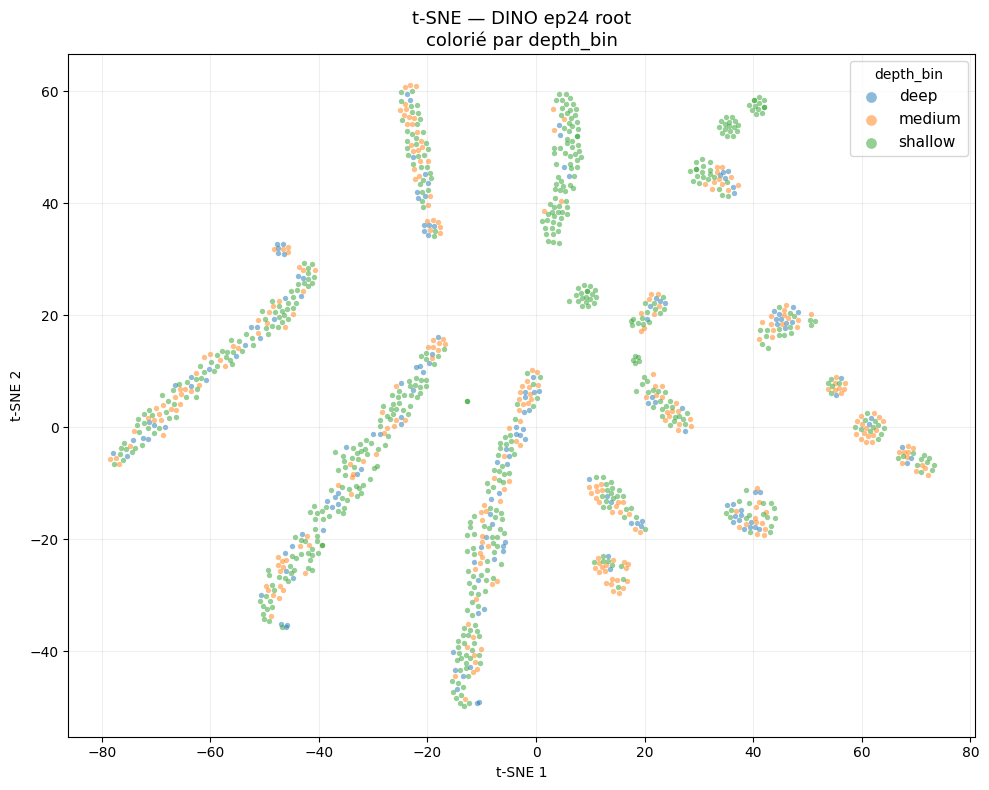

  Sauvegardé → tsne_DINO ep24 root_depth_bin.png

── t-SNE → DINO ep24 mean ─────────────────────────────


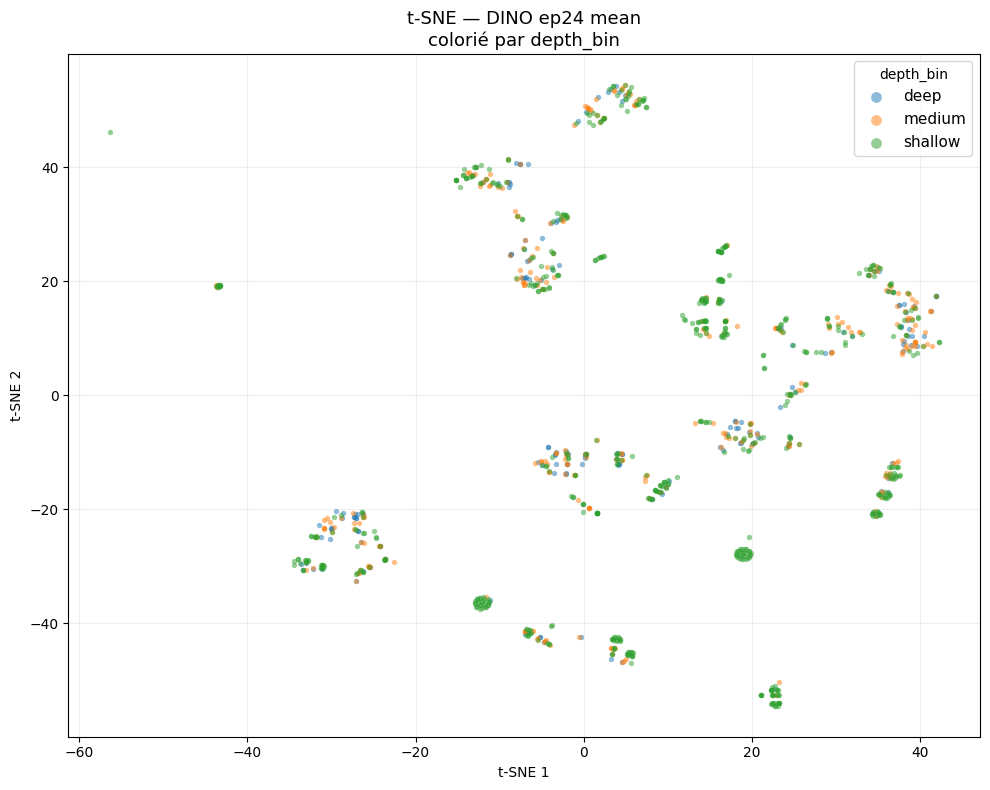

  Sauvegardé → tsne_DINO ep24 mean_depth_bin.png

── t-SNE → DINO ep4 root ─────────────────────────────


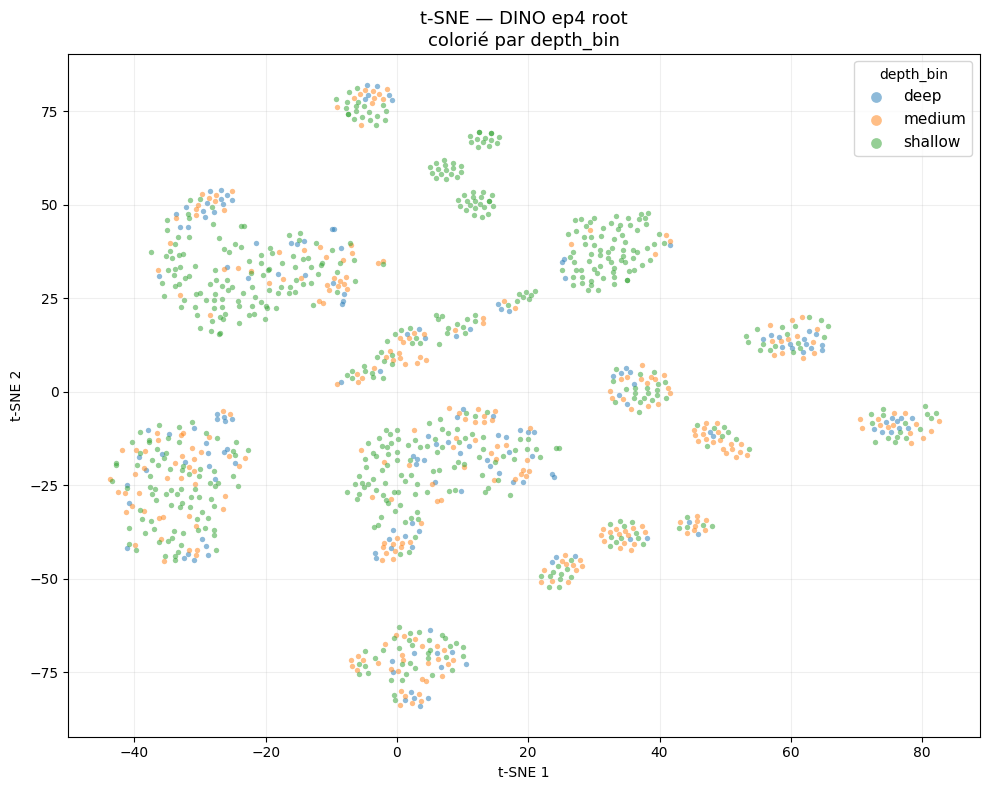

  Sauvegardé → tsne_DINO ep4 root_depth_bin.png

── t-SNE → DINO ep4 mean ─────────────────────────────


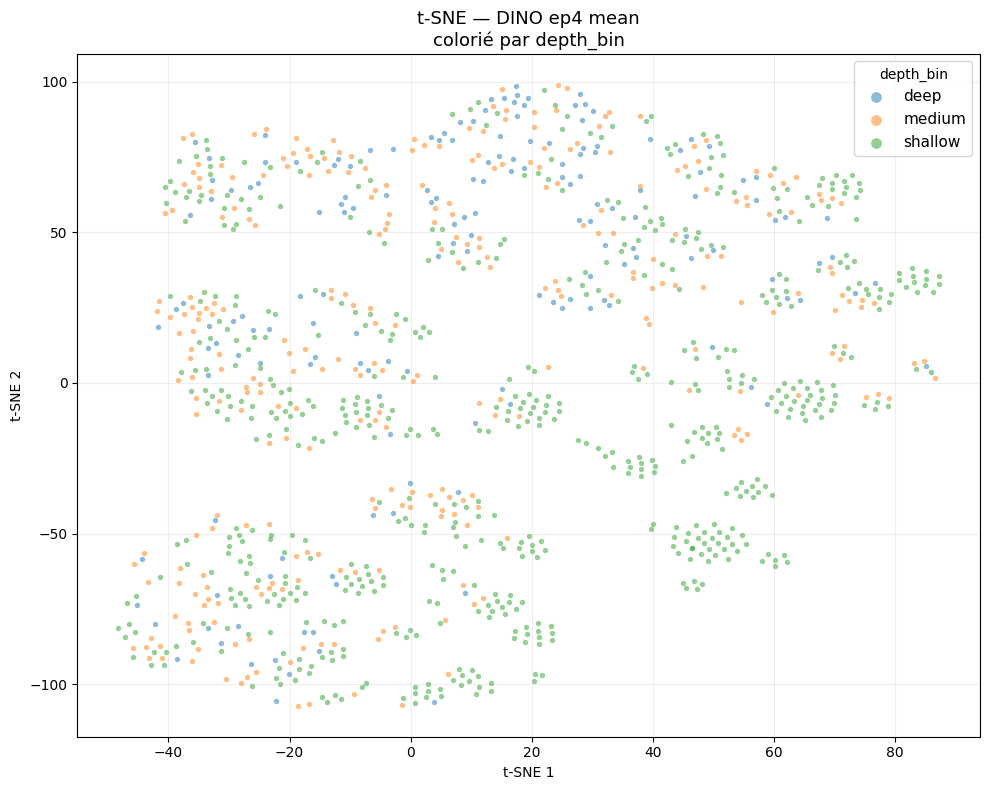

  Sauvegardé → tsne_DINO ep4 mean_depth_bin.png

── t-SNE → GFormers rnd root ─────────────────────────────


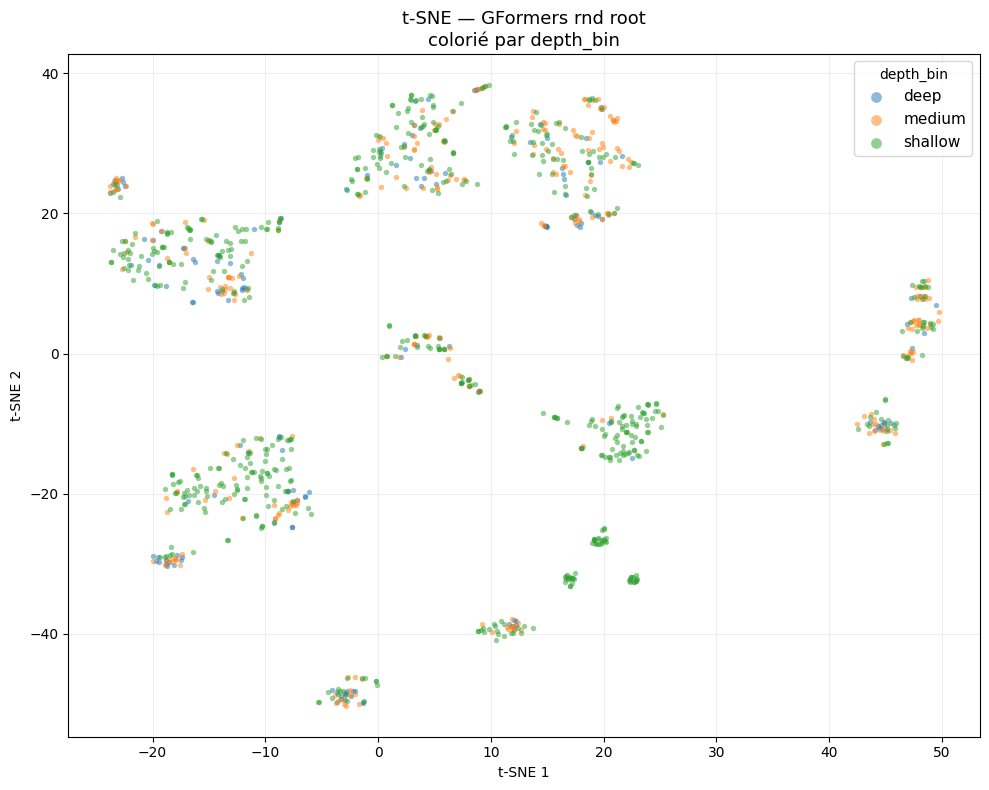

  Sauvegardé → tsne_GFormers rnd root_depth_bin.png

── t-SNE → GFormers rnd mean ─────────────────────────────


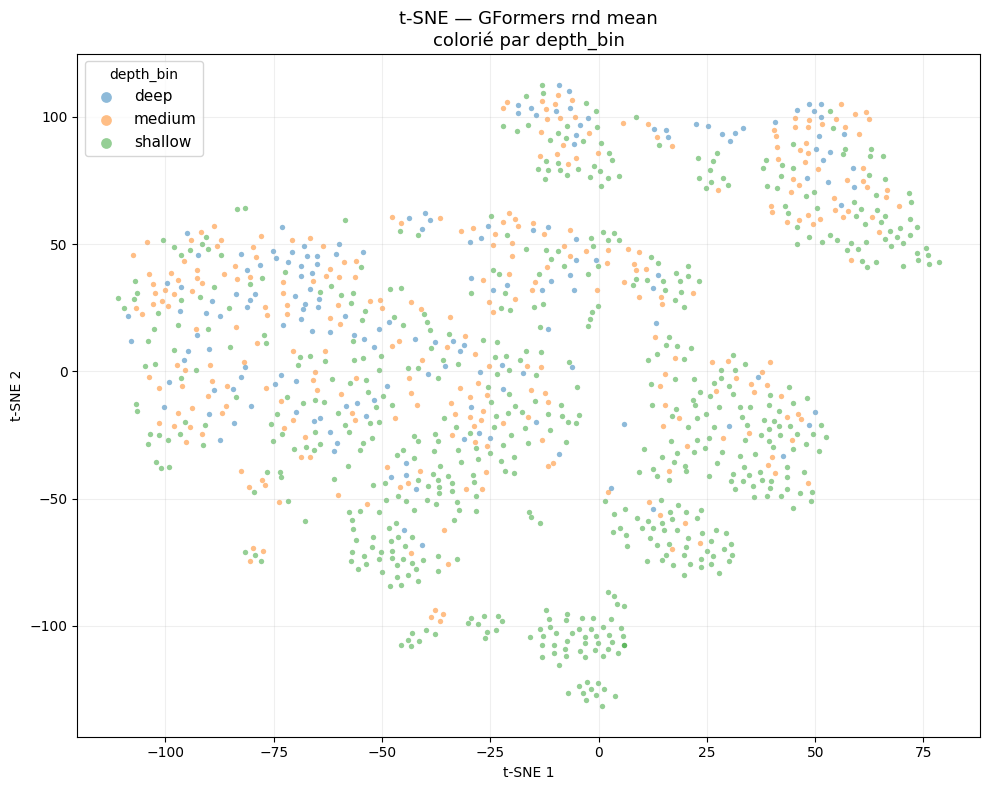

  Sauvegardé → tsne_GFormers rnd mean_depth_bin.png

── t-SNE → BERT brut ─────────────────────────────


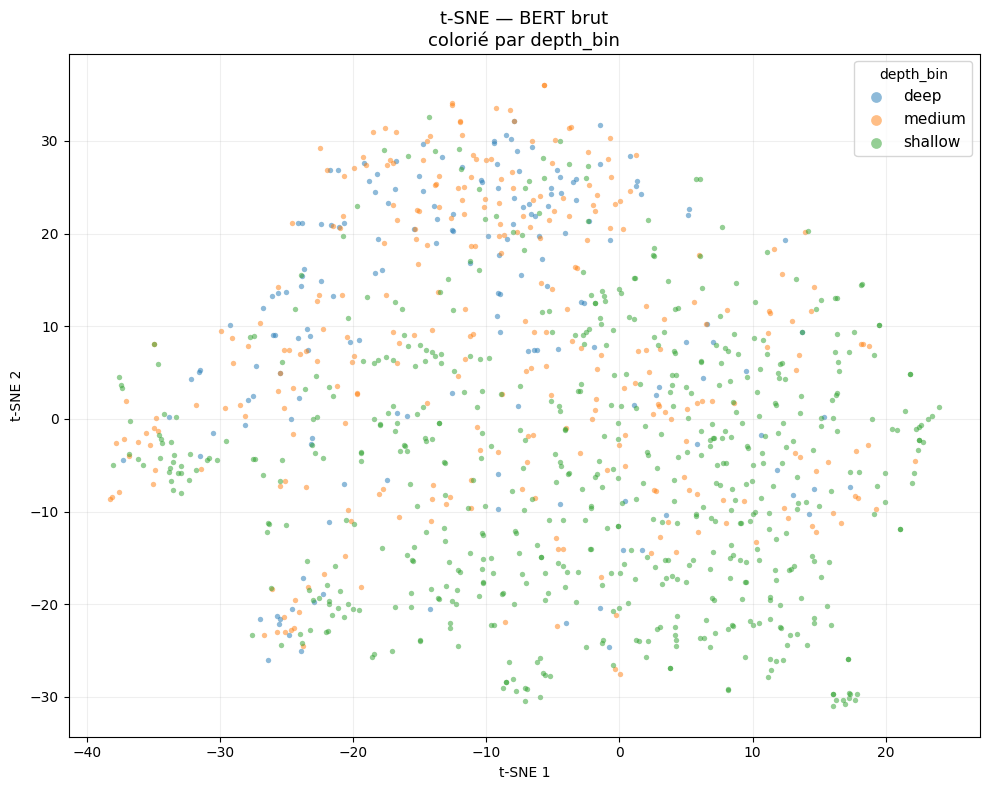

  Sauvegardé → tsne_BERT brut_depth_bin.png


In [33]:
# 1. Embeddings root-only (actuel)
embeddings        = extract_embeddings(backbone,        penman_strings)
embeddings_base   = extract_embeddings(backbone_base,   penman_strings)
embeddings_random = extract_embeddings(backbone_random, penman_strings)

# 2. Embeddings mean-pooling (aligné sur le training)
embeddings_mp        = extract_embeddings_mean_pooling(backbone,        penman_strings)
embeddings_base_mp   = extract_embeddings_mean_pooling(backbone_base,   penman_strings)
embeddings_random_mp = extract_embeddings_mean_pooling(backbone_random, penman_strings)


bert_embeddings   = extract_bert_embeddings(penman_strings)

print(f"\nEmbeddings shape  : {embeddings.shape}")
print(f"Norme moyenne     : {np.linalg.norm(embeddings, axis=1).mean():.4f}")
print(f"Norme std         : {np.linalg.norm(embeddings, axis=1).std():.4f}")

# 2. Labels structurels
print("\nExtraction des labels structurels...")
struct_df = extract_structural_labels(penman_strings)
print(struct_df.describe())

struct_df["depth_bin"] = pd.qcut(
    struct_df["depth"].dropna(), q=3,
    labels=["shallow", "medium", "deep"],
).reindex(struct_df.index)

struct_df["size_bin"] = pd.qcut(
    struct_df["node_count"].dropna(), q=3,
    labels=["small", "medium", "large"],
).reindex(struct_df.index)

# 3. Toutes les méthodes à évaluer
embedding_methods = [
    ("DINO ep24 root",    embeddings),
    ("DINO ep24 mean",    embeddings_mp),
    ("DINO ep4 root",     embeddings_base),
    ("DINO ep4 mean",     embeddings_base_mp),
    ("GFormers rnd root", embeddings_random),
    ("GFormers rnd mean", embeddings_random_mp),
    ("BERT brut",         bert_embeddings),
]
tasks = [
    ("depth_bin",         "Profondeur (bins)",     "classification"),
    ("size_bin",          "Taille graphe (bins)",  "classification"),
    ("has_negation",      "Négation",              "classification"),
    ("has_interrogative", "Mode (interrog/imper)", "classification"),
    ("arg_count",         "Nb ARGs",               "regression"),
    ("node_count",        "Nb nœuds",              "regression"),
]

# scores[method_name][task_name] = score
scores = {name: {} for name, _ in embedding_methods}

for col, task_name, ttype in tasks:
    labels_task = struct_df[col].values
    valid       = pd.notna(labels_task)
    lab         = np.array(labels_task[valid])

    print(f"\n{'═'*60}")
    print(f"  Tâche : {task_name}  ({ttype})")
    print(f"{'═'*60}")

    for method_name, emb in embedding_methods:
        emb_valid = emb[valid]
        X_tr, X_te, y_tr, y_te = train_test_split(
            emb_valid, lab, test_size=0.2, random_state=42,
            stratify=lab if ttype == "classification" else None,
        )
        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        if ttype == "classification":
            clf  = LogisticRegression(max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr)
            score = clf.score(X_te, y_te)
        else:
            reg   = Ridge()
            reg.fit(X_tr, y_tr)
            score = r2_score(y_te, reg.predict(X_te))

        scores[method_name][task_name] = score
        metric_label = "acc" if ttype == "classification" else "R²"
        print(f"  {method_name:<20} {metric_label} = {score:.4f}")

# 4. Tableau récapitulatif
print(f"\n{'═'*60}")
print("  RÉSUMÉ COMPARATIF")
print(f"{'═'*60}")
task_names = [t[1] for t in tasks]
col_w = 22
print(f"  {'Tâche':<28}" + "".join(f"{m:<{col_w}}" for m, _ in embedding_methods))
print(f"  {'':<28}" + "".join(f"{'─'*18:<{col_w}}" for _ in embedding_methods))
for task_name in task_names:
    row = f"  {task_name:<28}"
    method_scores = [scores[m][task_name] for m, _ in embedding_methods]
    best = max(method_scores)
    for s in method_scores:
        marker = " ◀" if s == best else ""
        row += f"{s:.4f}{marker:<{col_w - 6}}"
    print(row)

# 5. t-SNE
for method_name, emb in embedding_methods:
    tsne_plot(
        emb,
        struct_df["depth_bin"].values,
        label_name="depth_bin",
        title=method_name,
        categorical=True,
    )